In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import spacy
from spacy.lang.es.examples import sentences 
import glob
from constants import BASE_PATH
import json
import pandas as pd
import text_cleaning as tc
from tqdm.auto import tqdm
from collections import Counter

In [66]:
# !python -m spacy download es_core_news_sm

# Build Resources

In [3]:
json_paths  = glob.glob(f'{BASE_PATH}**/processed_gpt.json', recursive=True)

In [4]:
# nlp = spacy.load("es_core_news_sm")
nlp = spacy.blank("es")

In [5]:
text_pairs = []
for path in json_paths:
    print(path)
    with open(path, 'r') as f:
        d = json.load(f)
    
    for t in d['gpt_fixed']:
        try:
            text_pairs.append({
                'raw_text': t['raw_text'],
                'gpt_fixed_conservative': t['gpt_fixed_conservative']
            })
        except:
            continue

data/loc/2013201074/1855/11/03/ed-1/seq-2/processed_gpt.json
data/loc/2013201074/1855/06/21/ed-1/seq-2/processed_gpt.json
data/loc/2013201074/1863/11/24/ed-1/seq-4/processed_gpt.json
data/loc/2013201074/1863/11/24/ed-1/seq-2/processed_gpt.json
data/loc/2013201074/1865/05/13/ed-1/seq-1/processed_gpt.json
data/loc/2013201074/1865/06/13/ed-1/seq-4/processed_gpt.json
data/loc/2013201074/1853/04/12/ed-1/seq-1/processed_gpt.json
data/loc/2013201074/1853/04/12/ed-1/seq-3/processed_gpt.json
data/loc/2013201074/1853/08/13/ed-1/seq-1/processed_gpt.json
data/loc/2013201074/1853/06/21/ed-1/seq-2/processed_gpt.json
data/loc/2013201074/1853/12/10/ed-1/seq-2/processed_gpt.json
data/loc/2013201074/1860/06/09/ed-1/seq-4/processed_gpt.json
data/loc/2013201074/1867/02/19/ed-1/seq-4/processed_gpt.json
data/loc/2013201074/1867/01/12/ed-1/seq-4/processed_gpt.json
data/loc/2013201074/1867/06/20/ed-1/seq-4/processed_gpt.json
data/loc/2013201074/1866/03/15/ed-1/seq-4/processed_gpt.json
data/loc/2013201074/1866

In [6]:
len(text_pairs)

3961

In [7]:
phrase_counter, word_pair_counter, word_raw_totals = tc.mine_patches_and_words(
    text_pairs,
    nlp=nlp,
    phrase_min_span=2,
    phrase_max_span=5,
    include_newlines_in_phrases=False,
    lowercase_word_key=False,
)


In [8]:
phrase_patches = tc.finalize_phrase_patches(phrase_counter, min_count=2)
word_repls = tc.finalize_word_replacements(word_pair_counter, word_raw_totals, min_count=2, min_precision=0.9)
word_map = tc.build_word_map(word_repls)

In [9]:
patch_index = tc.build_phrase_patch_index(phrase_patches)

# Build SymSpell Dict

In [11]:
from wordfreq import top_n_list, zipf_frequency
from symspellpy import SymSpell, Verbosity

In [12]:

def spanish_prior_words(min_zipf=3.0, max_words=200_000):
    """
    Return a set of common Spanish words that may not appear in corpus.
    min_zipf ≈ 3.0 keeps reasonably common words.
    """
    words = []
    for w in top_n_list("es", max_words):
        if zipf_frequency(w, "es") >= min_zipf:
            words.append(w)
    return words

In [24]:
json_paths  = glob.glob(f'{BASE_PATH}**/processed.json', recursive=True)
fixed_counts = Counter()
raw_counts = Counter()

In [25]:
for path in tqdm(json_paths):
    # print(path)
    with open(path, 'r') as f:
        try:
            d = json.load(f)
            for t in d['text_blocks_raw']:
                if len(t['text']) > 20:
                    raw_counts.update(tc.simple_tok(tc.preclean_ocr_text(t['text'].lower())))
                    fixed_counts.update(tc.simple_tok((t['text'].lower())))
        except json.JSONDecodeError as e:
                # Handle the specific error if decoding fails
                print("Error: Unable to decode JSON.")
                print("Details:", e)


  0%|          | 0/158122 [00:00<?, ?it/s]

Error: Unable to decode JSON.
Details: Expecting value: line 1 column 1 (char 0)


In [26]:
total_word_count = sum(raw_counts.values())
print(total_word_count)

273888401


In [27]:
final_counts = Counter()

for w, c in raw_counts.items():
    if len(w) < 3:
        continue
    if any(ch.isdigit() for ch in w):
        final_counts[w] += max(1, c // 10)
    else:
        final_counts[w] += min(c, 50)

for w, c in fixed_counts.items():
    if len(w) < 3:
        continue
    boost = min(c * 5, 500)
    final_counts[w] += boost

# reward agreement between raw and fixed
for w in final_counts:
    final_counts[w] += min(raw_counts.get(w, 0), fixed_counts.get(w, 0)) * 2

In [28]:
for w in spanish_prior_words(min_zipf=2.0):
    if w not in final_counts:
        # convert Zipf to a small pseudo-count
        z = zipf_frequency(w, "es")
        final_counts[w] += max(1, int(10 ** (z - 4)))

In [ ]:
min_count=10
with open('data/resources/sysmspell_dict.txt', "w", encoding="utf8") as f:
    for w, c in final_counts.items():
        if c >= min_count:
            f.write(f"{w}\t{c}\n")

## Build Vocab

In [29]:
vocab_set = tc.build_vocab_set(fixed_counts, raw_counts)
for w in spanish_prior_words(min_zipf=4.0):
    vocab_set.add(w)

In [ ]:
# !pip install symspellpy wordfreq rapidfuzz

# Fix OCR Text

## Load Symspell

In [30]:
symspell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)

symspell.load_dictionary(
    "./data/resources/sysmspell_dict.txt",
    term_index=0,
    count_index=1,
    separator="\t",
    encoding="utf8"
)

True

## Token fix loop

In [18]:
from collections import defaultdict

In [21]:
CONFUSIONS = {
    '(jibar': 'Gibar'
}

In [ ]:
results = []
for text_pair in text_pairs:
    doc = nlp(text_pair['raw_text']) 
    fixed = tc.fix_ocr_doc(
        doc,
        nlp=nlp,
        patch_index=patch_index,
        symspell=symspell,
        vocab_set=vocab_set,
        word_map=word_map,
        use_word_map=False,          # toggle this to test harm/help
        min_score_gain=0.8,
        confusion_pairs=CONFUSIONS,  # optional
    )
    res = tc.evaluate_ocr_fix(doc, nlp(text_pair['gpt_fixed_conservative']), fixed) 
    results.append(res)
    print(res['damage_rate'], res['edit_precision'], res['edit_recall'])

In [37]:
'(jibar' in vocab_set

False

In [32]:
fixed = tc.fix_ocr_doc(
    nlp('De Génova, en 46 dias, berg. ing. Violet, capitán Pedro Alien, en (jibaro'),
    nlp=nlp,
    patch_index=patch_index,
    symspell=symspell,
    vocab_set=vocab_set,
    word_map=word_map,
    use_word_map=False,          # toggle this to test harm/help
    min_score_gain=0.8,
    confusion_pairs=CONFUSIONS,  # optional
)

In [33]:
fixed

De Génova, en 46 dias, berg. ing. Violet, capitán Pedro Alien, en (jibaro

<Axes: ylabel='Frequency'>

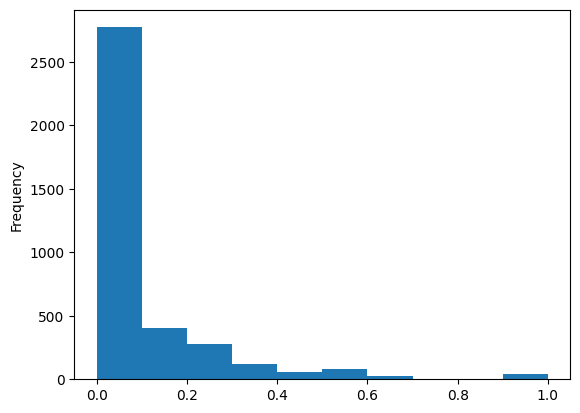

In [286]:
results_df = pd.DataFrame(results)
results_df['damage_rate'].plot.hist()

<Axes: ylabel='Frequency'>

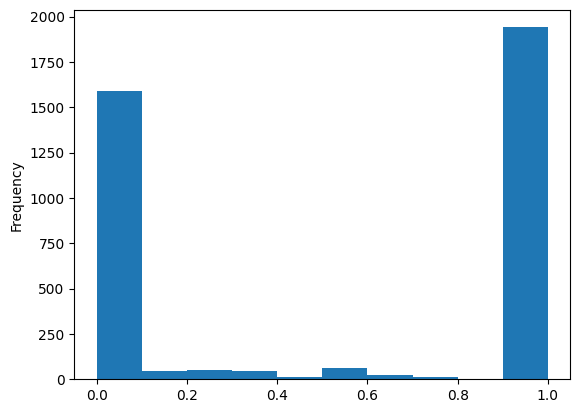

In [278]:
results_df = pd.DataFrame(results)
results_df['edit_precision'].plot.hist()

# Run on all text

In [38]:
json_paths  = glob.glob(f'{BASE_PATH}**/processed.json', recursive=True)
processed_json_paths  = []#[f.replace('cleaned', 'processed') for f in glob.glob(f'{BASE_PATH}**/cleaned.json', recursive=True)]

In [39]:
len(json_paths), len(processed_json_paths), len(processed_json_paths)/len(json_paths)

(158122, 0, 0.0)

In [40]:
for path in tqdm(json_paths):
    if path in processed_json_paths:
        continue
    try:
        with open(path, 'r') as f:
            d = json.load(f)
            cleaned = []
            for text in d['text_blocks_raw']:
                doc = nlp(text['text'].lower().replace('(jibar', 'gibar')) 
                fixed = tc.fix_ocr_doc(
                    doc,
                    nlp=nlp,
                    patch_index=patch_index,
                    symspell=symspell,
                    vocab_set=vocab_set,
                    word_map=word_map,
                    use_word_map=False,          # toggle this to test harm/help
                    min_score_gain=0.8,
                    confusion_pairs=CONFUSIONS,  # optional
                )
                c = text.copy()
                c['text'] = fixed.text
                cleaned.append(c)
                d['text_blocks_cleaned'] = cleaned
            with open(path.replace('processed.json', 'cleaned.json'), 'w') as json_file:
                json.dump(d, json_file)
    except:
        print("Error", path)

  0%|          | 0/158122 [00:00<?, ?it/s]

Error data/loc/2013201074/1868/12/22/ed-1/seq-2/processed.json


In [327]:
1

1

In [301]:
d['text_blocks_cleaned'] = cleaned

'V'